# Generalized Linear Models

## Loading the Data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

# ── Titanic dataset ────────────────────────────────────────────────────────
url_titanic = (
    "https://raw.githubusercontent.com/shoukewei/"
    "data-model/refs/heads/main/data/raw/titanic.csv"
)

df_titanic = pd.read_csv(url_titanic)

# if the data are available in the `./data/raw` directory
# df_titanic = pd.read_csv(DATA_RAW / "titanic.csv")

# Encode sex as binary; drop rows with missing age
df_titanic["Sex_female"] = (df_titanic["Sex"] == "female").astype(int)
df_titanic = df_titanic.dropna(subset=["Age"]).reset_index(drop=True)

# ── Bike Sharing dataset (hourly) ──────────────────────────────────────────
url_bike = (
    "https://raw.githubusercontent.com/shoukewei/"
    "data-model/refs/heads/main/data/raw/bike_sharing_hourly.csv"
)

df_bike = pd.read_csv(url_bike)

# if the data are available in the `./data/raw` directory
# df_bike = pd.read_csv(DATA_RAW / "bike_sharing_hourly.csv")

print("=== Titanic ===")
print(f"  Rows: {df_titanic.shape[0]:,}  |  Columns: {df_titanic.shape[1]}")
print(f"  Survival rate: {df_titanic['Survived'].mean():.3f}")
print(f"  Columns: {df_titanic.columns.tolist()}")

print("\n=== Bike Sharing ===")
print(f"  Rows: {df_bike.shape[0]:,}  |  Columns: {df_bike.shape[1]}")
print(f"  Mean rentals/hr: {df_bike['cnt'].mean():.1f}  |  "
      f"Std: {df_bike['cnt'].std():.1f}  |  Max: {df_bike['cnt'].max()}")

=== Titanic ===
  Rows: 714  |  Columns: 13
  Survival rate: 0.406
  Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Sex_female']

=== Bike Sharing ===
  Rows: 17,379  |  Columns: 17
  Mean rentals/hr: 189.5  |  Std: 181.4  |  Max: 977


## Logistic Regression

### Fitting the Model

In [6]:
import statsmodels.formula.api as smf

# ── Logistic regression: survived ~ pclass + sex_female + age + fare ───────
m_logit = smf.logit(
    "Survived ~ Pclass + Sex_female + Age + Fare",
    data=df_titanic
).fit()

print(m_logit.summary().tables[1])
print(f"\nMcFadden pseudo-R²: {m_logit.prsquared:.4f}")
print(f"AIC:                {m_logit.aic:.2f}")
print(f"Log-likelihood:     {m_logit.llf:.2f}")

Optimization terminated successfully.
         Current function value: 0.453242
         Iterations 6
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.4698      0.525      4.707      0.000       1.442       3.498
Pclass        -1.2697      0.159     -8.005      0.000      -1.581      -0.959
Sex_female     2.5182      0.208     12.115      0.000       2.111       2.926
Age           -0.0367      0.008     -4.780      0.000      -0.052      -0.022
Fare           0.0005      0.002      0.246      0.805      -0.004       0.005

McFadden pseudo-R²: 0.3290
AIC:                657.23
Log-likelihood:     -323.61


### Interpreting Coefficients: Odds Ratios

In [7]:
# ── Odds ratios with 95% CIs ───────────────────────────────────────────────
coef_df = pd.DataFrame({
    "coef":   m_logit.params,
    "OR":     np.exp(m_logit.params),
    "CI_lo":  np.exp(m_logit.conf_int()[0]),
    "CI_hi":  np.exp(m_logit.conf_int()[1]),
    "p":      m_logit.pvalues
}).drop("Intercept")

print(f"{'Variable':15s}  {'OR':>8}  {'95% CI':>22}  {'p':>8}")
print("-" * 62)
for var, row in coef_df.iterrows():
    sig = "***" if row["p"] < 0.001 else "**" if row["p"] < 0.01 else "*" if row["p"] < 0.05 else ""
    print(f"{var:15s}  {row['OR']:8.4f}  "
          f"[{row['CI_lo']:7.4f}, {row['CI_hi']:7.4f}]  {row['p']:8.4f} {sig}")

Variable               OR                  95% CI         p
--------------------------------------------------------------
Pclass             0.2809  [ 0.2058,  0.3833]    0.0000 ***
Sex_female        12.4062  [ 8.2549, 18.6452]    0.0000 ***
Age                0.9640  [ 0.9496,  0.9786]    0.0000 ***
Fare               1.0005  [ 0.9963,  1.0048]    0.8055 


### Visualising the Logistic Curve and Predictions

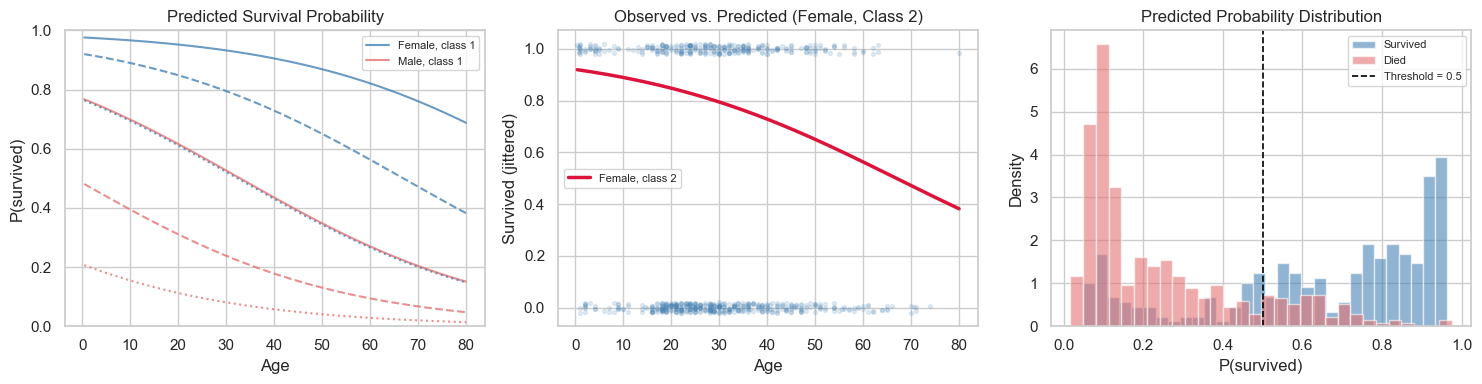

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: sigmoid curve coloured by sex
age_grid = np.linspace(df_titanic["Age"].min(), df_titanic["Age"].max(), 200)
for pclass_val, ls in zip([1, 2, 3], ["-", "--", ":"]):
    for sex_val, color, label in [(1, "steelblue", "Female"), (0, "#E57373", "Male")]:
        eta = (m_logit.params["Intercept"]
               + m_logit.params["Pclass"]     * pclass_val
               + m_logit.params["Sex_female"] * sex_val
               + m_logit.params["Age"]        * age_grid
               + m_logit.params["Fare"]       * df_titanic["Fare"].median())
        prob_curve = 1 / (1 + np.exp(-eta))
        lbl = f"{label}, class {pclass_val}" if pclass_val == 1 else None
        axes[0].plot(age_grid, prob_curve, color=color, lw=1.5, linestyle=ls,
                     alpha=0.8, label=lbl)
axes[0].set_title("Predicted Survival Probability")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("P(survived)")
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)

# Panel 2: observed jitter + predicted probability vs age
jitter = np.random.uniform(-0.02, 0.02, len(df_titanic))
axes[1].scatter(df_titanic["Age"],
                df_titanic["Survived"] + jitter,
                alpha=0.15, s=8, color="steelblue")
axes[1].plot(age_grid,
             1 / (1 + np.exp(-(m_logit.params["Intercept"]
                               + m_logit.params["Pclass"]     * 2
                               + m_logit.params["Sex_female"] * 1
                               + m_logit.params["Age"]        * age_grid
                               + m_logit.params["Fare"]       * df_titanic["Fare"].median()))),
             color="crimson", lw=2.5, label="Female, class 2")
axes[1].set_title("Observed vs. Predicted (Female, Class 2)")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Survived (jittered)")
axes[1].legend(fontsize=8)

# Panel 3: predicted probability distribution by outcome
survived_probs = m_logit.predict(df_titanic)
axes[2].hist(survived_probs[df_titanic["Survived"]==1], bins=30,
             alpha=0.6, color="steelblue", label="Survived", density=True)
axes[2].hist(survived_probs[df_titanic["Survived"]==0], bins=30,
             alpha=0.6, color="#E57373", label="Died", density=True)
axes[2].axvline(0.5, color="black", lw=1.2, linestyle="--", label="Threshold = 0.5")
axes[2].set_title("Predicted Probability Distribution")
axes[2].set_xlabel("P(survived)")
axes[2].set_ylabel("Density")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "ch07_logistic_fit.png", dpi=150, bbox_inches="tight")
plt.show()

## Model Evaluation for Binary Classifiers

### Confusion Matrix and Threshold Metrics

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, log_loss,
                              confusion_matrix, classification_report,
                              RocCurveDisplay)

# ── Train / test split ─────────────────────────────────────────────────────
feat_cols = ["Pclass", "Sex_female", "Age", "Fare"]
X = df_titanic[feat_cols].values
y = df_titanic["Survived"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

# ── Fit with sklearn ───────────────────────────────────────────────────────
lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_clf.fit(X_tr, y_tr)

y_pred = lr_clf.predict(X_te)
y_prob = lr_clf.predict_proba(X_te)[:, 1]

print("── Confusion matrix (rows=actual, cols=predicted) ──────────")
cm = confusion_matrix(y_te, y_pred)
print(f"              Predicted: died  Predicted: survived")
print(f"Actual: Died       {cm[0,0]:4d}               {cm[0,1]:4d}")
print(f"Actual: Surv       {cm[1,0]:4d}               {cm[1,1]:4d}")

print("\n── Classification report ───────────────────────────────────")
print(classification_report(y_te, y_pred, target_names=["Died", "Survived"]))

print("── Summary metrics ─────────────────────────────────────────")
print(f"  Accuracy:  {accuracy_score(y_te, y_pred):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_te, y_prob):.4f}")
print(f"  Log-loss:  {log_loss(y_te, y_prob):.4f}")

── Confusion matrix (rows=actual, cols=predicted) ──────────
              Predicted: died  Predicted: survived
Actual: Died         68                 19
Actual: Surv         16                 40

── Classification report ───────────────────────────────────
              precision    recall  f1-score   support

        Died       0.81      0.78      0.80        87
    Survived       0.68      0.71      0.70        56

    accuracy                           0.76       143
   macro avg       0.74      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143

── Summary metrics ─────────────────────────────────────────
  Accuracy:  0.7552
  AUC-ROC:   0.8110
  Log-loss:  0.5139


### ROC Curve and AUC

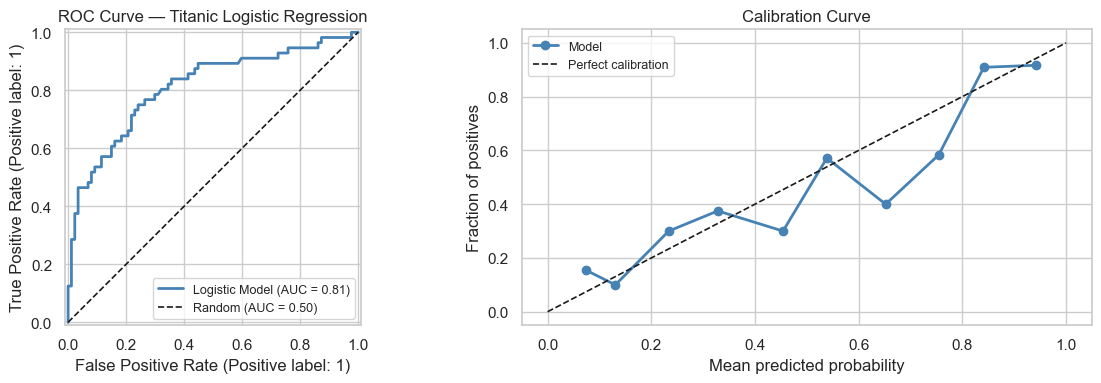

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: ROC curve
RocCurveDisplay.from_predictions(y_te, y_prob, ax=axes[0],
    curve_kwargs={"color": "steelblue", "lw": 2},
    name="Logistic Model")
axes[0].plot([0, 1], [0, 1], "k--", lw=1.2, label="Random (AUC = 0.50)")
axes[0].set_title("ROC Curve — Titanic Logistic Regression")
axes[0].legend(fontsize=9)

# Panel 2: calibration — predicted prob vs. observed fraction
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y_te, y_prob, n_bins=10)
axes[1].plot(mean_pred, frac_pos, "o-", color="steelblue", lw=2, label="Model")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.2, label="Perfect calibration")
axes[1].set_title("Calibration Curve")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Fraction of positives")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "ch07_roc_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

## Poisson Regression

### Fitting the Model

In [14]:
import statsmodels.api as sm

# ── Poisson GLM: cnt ~ weather + season + workingday + temp + hum + wind ───
m_pois = smf.glm(
    "cnt ~ temp + hum + windspeed + C(weathersit) + workingday + C(season)",
    data=df_bike,
    family=sm.families.Poisson()
).fit()

print(m_pois.summary().tables[1])
print(f"\nNull deviance:    {m_pois.null_deviance:,.2f}")
print(f"Residual deviance:{m_pois.deviance:,.2f}")
print(f"Pseudo R²:        {1 - m_pois.deviance/m_pois.null_deviance:.4f}")
print(f"AIC:              {m_pois.aic:,.2f}")

                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.6784      0.003   1374.216      0.000       4.672       4.685
C(weathersit)[T.2]     0.0902      0.001     65.805      0.000       0.088       0.093
C(weathersit)[T.3]    -0.1471      0.003    -53.481      0.000      -0.152      -0.142
C(weathersit)[T.4]     0.3873      0.067      5.781      0.000       0.256       0.519
C(season)[T.2]         0.1264      0.002     57.972      0.000       0.122       0.131
C(season)[T.3]        -0.0766      0.003    -29.224      0.000      -0.082      -0.072
C(season)[T.4]         0.4510      0.002    230.066      0.000       0.447       0.455
temp                   2.2515      0.005    479.956      0.000       2.242       2.261
hum                   -1.4174      0.003   -414.070      0.000      -1.424      -1.411
windspeed              0.2629      0.005   

### Interpreting Coefficients: Rate Ratios

In [15]:
# ── Rate ratios with 95% CIs ───────────────────────────────────────────────
rr_df = pd.DataFrame({
    "coef":  m_pois.params,
    "RR":    np.exp(m_pois.params),
    "CI_lo": np.exp(m_pois.conf_int()[0]),
    "CI_hi": np.exp(m_pois.conf_int()[1]),
    "p":     m_pois.pvalues
}).drop("Intercept")

print(f"{'Variable':30s}  {'RR':>8}  {'95% CI':>22}  {'p':>8}")
print("-" * 76)
for var, row in rr_df.iterrows():
    sig = "***" if row["p"] < 0.001 else ""
    print(f"{var:30s}  {row['RR']:8.4f}  "
          f"[{row['CI_lo']:7.4f}, {row['CI_hi']:7.4f}]  {row['p']:.4f} {sig}")

Variable                              RR                  95% CI         p
----------------------------------------------------------------------------
C(weathersit)[T.2]                1.0944  [ 1.0915,  1.0973]  0.0000 ***
C(weathersit)[T.3]                0.8632  [ 0.8586,  0.8679]  0.0000 ***
C(weathersit)[T.4]                1.4730  [ 1.2917,  1.6797]  0.0000 ***
C(season)[T.2]                    1.1348  [ 1.1299,  1.1396]  0.0000 ***
C(season)[T.3]                    0.9262  [ 0.9215,  0.9310]  0.0000 ***
C(season)[T.4]                    1.5699  [ 1.5638,  1.5759]  0.0000 ***
temp                              9.5019  [ 9.4150,  9.5897]  0.0000 ***
hum                               0.2423  [ 0.2407,  0.2440]  0.0000 ***
windspeed                         1.3006  [ 1.2886,  1.3128]  0.0000 ***
workingday                        1.0287  [ 1.0263,  1.0311]  0.0000 ***


### Visualising Poisson Fit

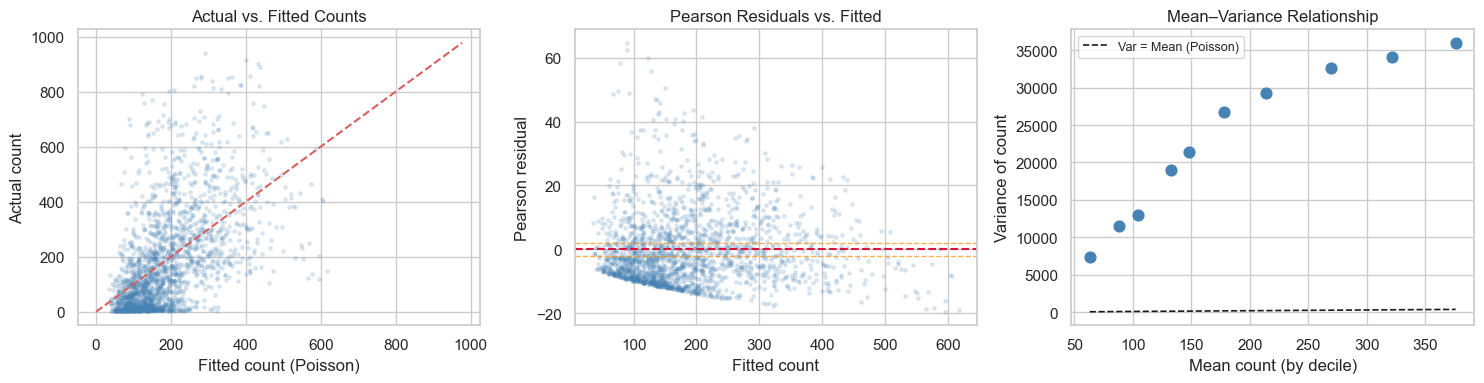

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: predicted vs. actual counts (sample 2000 for clarity)
sample_idx = np.random.choice(len(df_bike), 2000, replace=False)
fitted_pois = m_pois.fittedvalues
axes[0].scatter(fitted_pois.iloc[sample_idx],
                df_bike["cnt"].iloc[sample_idx],
                alpha=0.15, s=6, color="steelblue")
lims = [0, max(fitted_pois.max(), df_bike["cnt"].max())]
axes[0].plot(lims, lims, "r--", lw=1.5)
axes[0].set_title("Actual vs. Fitted Counts")
axes[0].set_xlabel("Fitted count (Poisson)")
axes[0].set_ylabel("Actual count")

# Panel 2: Pearson residuals
pearson_resid = (df_bike["cnt"] - fitted_pois) / np.sqrt(fitted_pois)
axes[1].scatter(fitted_pois.iloc[sample_idx],
                pearson_resid.iloc[sample_idx],
                alpha=0.15, s=6, color="steelblue")
axes[1].axhline(0, color="crimson", lw=1.5, linestyle="--")
axes[1].axhline(2,  color="darkorange", lw=1, linestyle="--", alpha=0.7)
axes[1].axhline(-2, color="darkorange", lw=1, linestyle="--", alpha=0.7)
axes[1].set_title("Pearson Residuals vs. Fitted")
axes[1].set_xlabel("Fitted count")
axes[1].set_ylabel("Pearson residual")

# Panel 3: mean vs. variance by fitted decile (overdispersion check)
df_bike["fitted"] = fitted_pois
df_bike["decile"] = pd.qcut(fitted_pois, 10, labels=False)
decile_stats = df_bike.groupby("decile")["cnt"].agg(["mean", "var"]).reset_index()
axes[2].scatter(decile_stats["mean"], decile_stats["var"],
                s=60, color="steelblue", zorder=3)
diag = np.linspace(decile_stats["mean"].min(), decile_stats["mean"].max(), 100)
axes[2].plot(diag, diag, "k--", lw=1.2, label="Var = Mean (Poisson)")
axes[2].set_title("Mean–Variance Relationship")
axes[2].set_xlabel("Mean count (by decile)")
axes[2].set_ylabel("Variance of count")
axes[2].legend(fontsize=9)
df_bike.drop(columns=["fitted", "decile"], inplace=True)

plt.tight_layout()
plt.savefig(FIGURES / "ch07_poisson_fit.png", dpi=150, bbox_inches="tight")
plt.show()

## Overdispersion and Model Diagnostics

In [17]:
# ── Overdispersion check ───────────────────────────────────────────────────
obs_mean = df_bike["cnt"].mean()
obs_var  = df_bike["cnt"].var()
disp_ratio = obs_var / obs_mean

# Dispersion parameter from residual deviance
disp_param = m_pois.deviance / m_pois.df_resid

print(f"Observed mean:          {obs_mean:.2f}")
print(f"Observed variance:      {obs_var:.2f}")
print(f"Var / Mean ratio:       {disp_ratio:.2f}  (Poisson expects ≈ 1.0)")
print(f"Deviance / df_resid:    {disp_param:.4f}  (Poisson expects ≈ 1.0)")
print(f"\nConclusion: {'OVERDISPERSED' if disp_ratio > 1.5 else 'OK'} "
      f"(ratio = {disp_ratio:.1f}×)")

Observed mean:          189.46
Observed variance:      32901.46
Var / Mean ratio:       173.66  (Poisson expects ≈ 1.0)
Deviance / df_resid:    117.2757  (Poisson expects ≈ 1.0)

Conclusion: OVERDISPERSED (ratio = 173.7×)


### Quasi-Poisson: Correcting for Overdispersion

In [18]:
# ── Quasi-Poisson: same coefficients, corrected SEs ───────────────────────
m_quasi = smf.glm(
    "cnt ~ temp + hum + windspeed + C(weathersit) + workingday + C(season)",
    data=df_bike,
    family=sm.families.Poisson()
).fit(scale="X2")   # scale by Pearson chi² / df → quasi-Poisson

print("Comparison: Poisson vs. Quasi-Poisson standard errors (selected vars)")
print(f"{'Variable':30s}  {'SE (Poisson)':>14}  {'SE (Quasi)':>12}  {'Inflation':>10}")
print("-" * 72)
for var in ["temp", "hum", "C(weathersit)[T.3]", "workingday"]:
    se_pois  = m_pois.bse[var]
    se_quasi = m_quasi.bse[var]
    print(f"{var:30s}  {se_pois:14.6f}  {se_quasi:12.6f}  "
          f"{se_quasi/se_pois:10.2f}×")

Comparison: Poisson vs. Quasi-Poisson standard errors (selected vars)
Variable                          SE (Poisson)    SE (Quasi)   Inflation
------------------------------------------------------------------------
temp                                  0.004691      0.052912       11.28×
hum                                   0.003423      0.038610       11.28×
C(weathersit)[T.3]                    0.002750      0.031017       11.28×
workingday                            0.001202      0.013553       11.28×


## Model Interpretation Across GLM Families

### Visualising Coefficient Effects

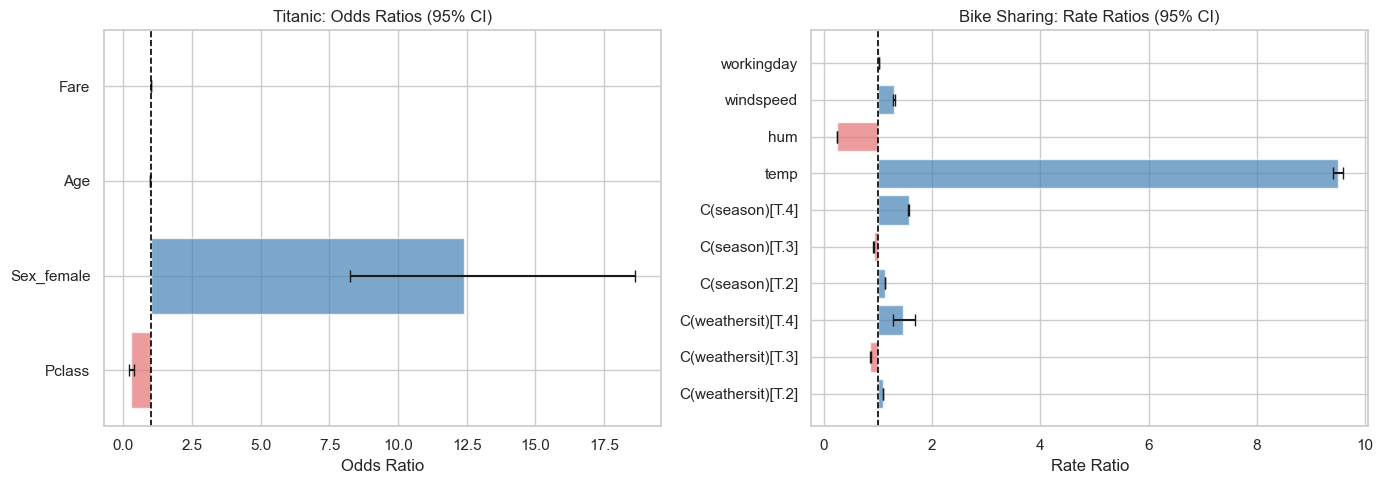

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Titanic — odds ratio forest plot
or_plot = coef_df.copy()
or_plot = or_plot[or_plot.index != "Intercept"]
y_pos = range(len(or_plot))
colors = ["steelblue" if or_ > 1 else "#E57373" for or_ in or_plot["OR"]]
axes[0].barh(list(y_pos), or_plot["OR"] - 1,
             xerr=[or_plot["OR"] - or_plot["CI_lo"],
                   or_plot["CI_hi"] - or_plot["OR"]],
             left=1, color=colors, alpha=0.7, capsize=4, edgecolor="white")
axes[0].axvline(1, color="black", lw=1.2, linestyle="--")
axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels(or_plot.index)
axes[0].set_title("Titanic: Odds Ratios (95% CI)")
axes[0].set_xlabel("Odds Ratio")

# Panel 2: Bike sharing — rate ratio forest plot
rr_plot = rr_df.copy()
y_pos2 = range(len(rr_plot))
colors2 = ["steelblue" if rr > 1 else "#E57373" for rr in rr_plot["RR"]]
axes[1].barh(list(y_pos2), rr_plot["RR"] - 1,
             xerr=[rr_plot["RR"] - rr_plot["CI_lo"],
                   rr_plot["CI_hi"] - rr_plot["RR"]],
             left=1, color=colors2, alpha=0.7, capsize=4, edgecolor="white")
axes[1].axvline(1, color="black", lw=1.2, linestyle="--")
axes[1].set_yticks(list(y_pos2))
axes[1].set_yticklabels(rr_plot.index)
axes[1].set_title("Bike Sharing: Rate Ratios (95% CI)")
axes[1].set_xlabel("Rate Ratio")

plt.tight_layout()
plt.savefig(FIGURES / "ch07_effect_plots.png", dpi=150, bbox_inches="tight")
plt.show()